# Defining the physics

In [1]:
detector = "V03422A"
measure = "am_HS1_top_dlt"

# GDLM file generation

In [2]:
import dbetto
import pygeomhades
import pygeomtools
from pygeomtools import write_pygeom
import pyg4ometry as pg4
from pyg4ometry import gdml
import lh5
import os
import numpy as np
import matplotlib.pyplot as plt

In [3]:
metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
db = dbetto.TextDB(metadata_path)

configuration = (
    db.hardware.configuration[detector]
    ["c1"]
    [measure]
    ["run0001"]
)

reg = pygeomhades.core.construct(configuration)
# visualise
#pygeomtools.viewer.visualize(reg)


Translation to detector from for am_HS1 and r!=0 is uncertain. Proceed with caution.


In [4]:

output_dir = f"/global/u2/r/ritaferi/HADES_DATA/MC/{detector}"
os.makedirs(output_dir, exist_ok=True)

output_file = os.path.join(
    output_dir,
    f"{detector}_{measure}_run0001.gdml"
)

write_pygeom(reg, output_file)

print(f"File GDML creato: {output_file}")

File GDML creato: /global/u2/r/ritaferi/HADES_DATA/MC/V03422A/V03422A_am_HS1_top_dlt_run0001.gdml


# Geometry check

In [5]:


def generic_polycone_profile(solid):
    r = np.asarray(
        solid.evaluateParameterWithUnits("pR"),
        dtype=float
    )
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZ"),
        dtype=float
    )

    return np.append(r, r[0]), np.append(z, z[0])


def polycone_profile(solid):
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZpl"),
        dtype=float
    )
    rmin = np.asarray(
        solid.evaluateParameterWithUnits("pRMin"),
        dtype=float
    )
    rmax = np.asarray(
        solid.evaluateParameterWithUnits("pRMax"),
        dtype=float
    )

    r = np.concatenate([rmax, rmin[::-1], [rmax[0]]])
    z = np.concatenate([z, z[::-1], [z[0]]])

    return r, z

    
def get_profile(solid):
    solid_type = str(solid.type).lower()

    if "genericpolycone" in solid_type:
        return generic_polycone_profile(solid)

    if "polycone" in solid_type:
        return polycone_profile(solid)

    if "tubs" in solid_type or "tube" in solid_type:
        return tubs_profile(solid)

    if "box" in solid_type:
        return box_profile(solid)

    raise TypeError(
        f"Solido {solid.name} di tipo {solid.type} non supportato"
    )

In [6]:
def evaluate_vector(vector):
    """Converte Position o Rotation di pyg4ometry in array numerico."""
    return np.asarray(vector.eval(), dtype=float)


def physical_volume_matrix(pv):
    """Matrice omogenea della trasformazione del PhysicalVolume."""
    position = evaluate_vector(pv.position)
    rotation = evaluate_vector(pv.rotation)

    rotation_matrix = np.linalg.inv(
        pg4.transformation.tbxyz2matrix(rotation)
    )

    matrix = np.eye(4)
    matrix[:3, :3] = rotation_matrix
    matrix[:3, 3] = position

    return matrix


def collect_global_placements(logical_volume, parent_matrix=None):
    """
    Percorre ricorsivamente il GDML e restituisce la trasformazione
    globale di ogni volume fisico.
    """
    if parent_matrix is None:
        parent_matrix = np.eye(4)

    placements = {}

    def walk(mother_lv, mother_matrix):
        for pv in mother_lv.daughterVolumes:
            local_matrix = physical_volume_matrix(pv)
            global_matrix = mother_matrix @ local_matrix

            logical_name = pv.logicalVolume.name

            placements.setdefault(logical_name, []).append({
                "physical_name": pv.name,
                "logical_volume": pv.logicalVolume,
                "matrix": global_matrix,
            })

            walk(pv.logicalVolume, global_matrix)

    walk(logical_volume, parent_matrix)

    return placements

In [7]:
def find_germanium_detector(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Germanium" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessun detector al germanio trovato")

    if len(candidates) > 1:
        print("Detector al germanio trovati:", candidates)

    return candidates[0]

In [8]:
def find_source(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Source" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessuna sorgente trovate")

    if len(candidates) > 1:
        print("Sorgente trovata:", candidates)

    return candidates[0]

In [9]:
def tubs_profile(solid):
    """Profilo r-z di un cilindro Tubs."""

    rmin = float(solid.evaluateParameterWithUnits("pRMin"))
    rmax = float(solid.evaluateParameterWithUnits("pRMax"))
    dz = float(solid.evaluateParameterWithUnits("pDz"))

    # pDz è la lunghezza totale lungo z
    zmin = -dz / 2
    zmax = dz / 2

    r = np.array([
        rmin,
        rmax,
        rmax,
        rmin,
        rmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

In [10]:
def box_profile(solid):
    """Profilo nel piano locale x-z di un Box."""

    size_x = float(solid.evaluateParameterWithUnits("pX"))
    size_z = float(solid.evaluateParameterWithUnits("pZ"))

    xmin = -size_x / 2
    xmax = size_x / 2
    zmin = -size_z / 2
    zmax = size_z / 2

    r = np.array([
        xmin,
        xmax,
        xmax,
        xmin,
        xmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

In [11]:
def transform_profile(r, z, matrix):
    """
    Trasforma un profilo locale (r, z) nelle coordinate globali.

    Parameters
    ----------
    r : array-like
        Coordinate radiali locali.
    z : array-like
        Coordinate verticali locali.
    matrix : array-like, shape (4, 4)
        Matrice omogenea contenente rotazione e traslazione globali.

    Returns
    -------
    radius : ndarray
        Distanza globale dall'asse z.
    height : ndarray
        Coordinata z globale.
    """

    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    # Punti omogenei locali: (x=r, y=0, z, 1)
    points = np.column_stack([
        r,
        np.zeros_like(r),
        z,
        np.ones_like(r)
    ])

    # Trasformazione nelle coordinate globali
    transformed = (matrix @ points.T).T

    x_global = transformed[:, 0]
    y_global = transformed[:, 1]
    z_global = transformed[:, 2]

    radius = np.sqrt(x_global**2 + y_global**2)
    height = z_global

    return radius, height

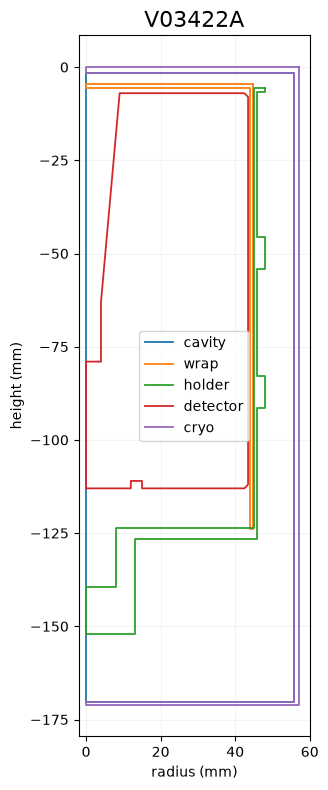

In [12]:
placements = collect_global_placements(reg.getWorldVolume())

detector_name = find_germanium_detector(reg)

components = {
    "cavity_lv": {
        "label": "cavity",
        "color": "tab:blue"
    },
    "Wrap": {
        "label": "wrap",
        "color": "tab:orange"
    },
    "Holder": {
        "label": "holder",
        "color": "tab:green"
    },
    detector_name: {
        "label": "detector",
        "color": "tab:red"
    },
    "Cryostat": {
        "label": "cryo",
        "color": "tab:purple"
    },
}

fig, ax = plt.subplots(figsize=(5, 8))

for logical_name, style in components.items():

    if logical_name not in placements:
        print(f"Volume non trovato: {logical_name}")
        continue

    # Se esistono più copie, le disegna tutte
    for index, placement in enumerate(placements[logical_name]):

        lv = placement["logical_volume"]
        matrix = placement["matrix"]

        try:
            r_local, z_local = get_profile(lv.solid)
        except TypeError as error:
            print(error)
            continue

        radius, height = transform_profile(
            r_local,
            z_local,
            matrix
        )

        # Una sola voce in legenda per componente
        label = style["label"] if index == 0 else None

        ax.plot(
            radius,
            height,
            color=style["color"],
            linewidth=1.3,
            label=label
        )

ax.set_title(detector_name, fontsize=16)
ax.set_xlabel("radius (mm)")
ax.set_ylabel("height (mm)")

ax.set_xlim(left=-2)
ax.set_aspect("equal", adjustable="box")

ax.grid(alpha=0.15)
ax.legend()

plt.tight_layout()
plt.show()

# Simulation

In [13]:
import awkward as ak
import hist
import matplotlib.pyplot as plt
import h5py
import glob
import numpy as np

from remage import remage_run
import lh5

In [14]:
macro = [
    "/RMG/Manager/Logging/LogLevel summary",

    "/RMG/Processes/HadronicPhysics Shielding",

    f"/RMG/Geometry/RegisterDetector Germanium {detector} 1",

    "/RMG/Output/NtupleUseVolumeName true",
    "/RMG/Output/NtuplePerDetector false",

    "/run/initialize",

    # Generatore confinato nel materiale attivo della sorgente
    "/RMG/Generator/Confine Volume",
    "/RMG/Generator/Confinement/Physical/AddVolume Source_PV",

    "/RMG/Generator/Select GPS",

    # CAMBIA QUI LO IONE -->thorio228
    "/gps/particle ion",
    "/gps/ion 90 228",
    "/gps/energy 0 keV",

    # Numero di nuclei
    "/run/beamOn 50",
]

try:
    remage_run(
        macros=macro,
        gdml_files=f"{detector}/{detector}_{measure}_run0001.gdml",
        output=f"{detector}/{detector}_{measure}_run0001.lh5",
        overwrite_output=True
    )

    print("✅ Simulazione completata")

except Exception as e:
    print(f"❌ Simulazione fallita: {e}")



  _ __ ___ _ __ ___   __ _  __ _  ___ 
 | '__/ _ \ '_ ` _ \ / _` |/ _` |/ _ \
 | | |  __/ | | | | | (_| | (_| |  __/ v1.1.0
 |_|  \___|_| |_| |_|\__,_|\__, |\___| using geant4-11-03-patch-02 [MT]
                           |___/      

G4GDML: Reading 'V03422A/V03422A_am_HS1_top_dlt_run0001.gdml'...
G4GDML: Reading definitions...
G4GDML: Reading materials...
G4GDML: Reading solids...
G4GDML: Reading structure...
G4GDML: Reading userinfo...
G4GDML: Reading setup...
G4GDML: Reading 'V03422A/V03422A_am_HS1_top_dlt_run0001.gdml' done!
Stripping off GDML names of materials, solids and volumes ...

-------- WWWW ------- G4Exception-START -------- WWWW -------
*** G4Exception : GeomVol1002
      issued by : G4PVPlacement::CheckOverlaps()
Overlap with volume already placed !
          Overlap is detected for volume wrap_pv_1:0 (G4Polycone) with holder_pv_1:0 (G4Polycone)
          overlap at local point (18.4217,40.6913,118.5) by 500 um  (max of 18 cases)
NOTE: Reached maximum fixed number -1-

[Summary -> CLHEP::HepRandom seed changed to: 791095027 (from system entropy)
[Summary -> Checking for overlaps in GDML geometry...
[Summary -> Opening output file: V03422A/.rmg-tmp-23191.V03422A_am_HS1_top_dlt_run0001.hdf5 (for V03422A/V03422A_am_HS1_top_dlt_run0001.lh5)
[Summary -> Starting run nr. 0. Current local time is 22-09-2026 08:59:44 PDT
[Summary -> Number of events to be processed: 50
[Summary -> Run nr. 0 completed. 50 events simulated. Current local time is 22-09-2026 08:59:44 PDT
[Summary -> Stats: run time was 0 days, 0 hours, 0 minutes and 0 seconds
[Summary -> Stats: average event processing time was 0.00074301 seconds/event = 1345.9 events/second
[Summary -> Stats: Event processing time might be inaccurate
[Summary -> Stats: on average, 0.0 iterations were needed to sample a valid vertex (100.0% efficiency)
[Summary -> Stats: average time to sample a vertex was 1.88900 us/event
[Summary -> Reshaping output files
[Summary -> processing V03422A/.V03422A_am_HS1_top_dlt_

✅ Simulazione completata


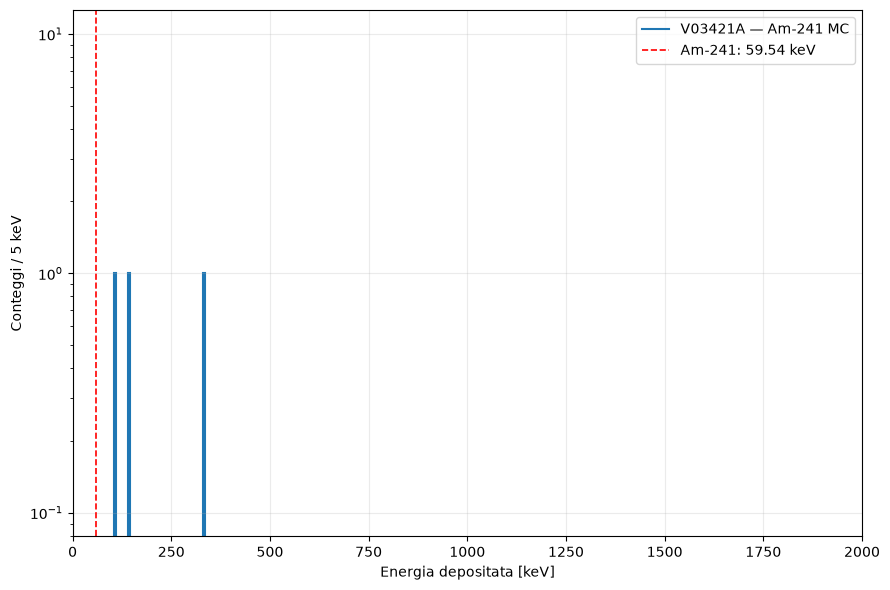

In [15]:

filename = f"{detector}/{detector}_{measure}_run0001.lh5"

data = lh5.read_as(
    "stp/germanium",
    filename,
    "ak"
)

# Energia totale depositata nel germanio per ogni evento
E_mc = ak.to_numpy(
    ak.sum(data.edep, axis=-1)
)

# Rimuove eventi senza deposizione e valori non validi
E_mc = E_mc[
    np.isfinite(E_mc) &
    (E_mc > 0)
]

# Impostazioni istogramma
bin_width = 5       # keV
energy_max = 2000   # keV
n_bins = int(energy_max / bin_width)

h_mc = (
    hist.new
    .Reg(
        n_bins,
        0,
        energy_max,
        name="energy",
        label="Energy [keV]"
    )
    .Double()
)

h_mc.fill(E_mc)

plt.figure(figsize=(9, 6))

h_mc.plot(
    yerr=False,
    label="V03421A — Am-241 MC"
)

# Riga gamma principale dell'Am-241
plt.axvline(
    59.54,
    color="red",
    linestyle="--",
    linewidth=1.2,
    label="Am-241: 59.54 keV"
)

plt.xlabel("Energia depositata [keV]")
plt.ylabel(f"Conteggi / {bin_width} keV")
plt.yscale("log")
plt.xlim(0, 2000)
plt.grid(alpha=0.25)
plt.legend()

plt.tight_layout()
plt.show()

# prova